In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from pmt_fit_helpers import stage1_loss, simulate_gain, get_param, BASE_INC

# 7-point gain-vs-HV dataset (kept as the fit target per prior decision -- the denser
# datasheet CSV, R12699_gain_from_datasheet.csv, is intentionally left unused here)
target_voltage = np.array([800., 850., 900., 950., 1000., 1050., 1100.])
target_gain = np.array([2.72E+05, 4.39E+05, 6.89E+05, 1.06E+06, 1.58E+06, 2.33E+06, 3.37E+06])

N_PE_LINEAR = 10  # low enough to keep every dynode far below its space-charge knee (see margin check below)

In [2]:
import json
from pathlib import Path

# Set to False to force re-running both optimizers even if cached fit results exist.
USE_CACHED_FITS = True
STAGE1_CACHE = Path("stage1_fit_result.json")
STAGE2_CACHE = Path("stage2_fit_result.json")

### PMT per-dynode gain: `gain_0`, `k_gen`

Each dynode stage amplifies the incoming current by a gain $g_i$ that depends on the
voltage across that dynode gap, $\Delta V_i$:

$$I_i = g_i \, I_{i-1}$$

$g_i$ is a power law in $\Delta V_i$, with a low-voltage cutoff term:

$$g_i = k_{\rm gen}(\Delta V_i)\,\Delta V_i^{\,a}, \qquad
k_{\rm gen}(V) = \frac{k}{\sqrt{1 + V_0/V}}$$

In `pmt_model_v4.inc` this is `k_gen(V)` / `gain_0(V)`, with `V` floored at `Vmin=1mV`
via `vclamp(V) = max(V, Vmin)` purely to avoid a divide-by-zero at $V=0$ (real dynode
gaps never actually reach 0V). `k`, `a` are free parameters fit in Stage 1 below;
`V_0` is currently fixed at 0.

### Collection efficiency: `eta`

Not every electron emitted by one dynode is actually collected by the next --
`eta(V, Vknee)` models this as a sigmoid in the gap voltage $V$:

$$\eta(V, V_{\rm knee}) = \frac{1}{1 + \exp\left(\dfrac{V_{\rm knee} - \max(V,0)}{V_{\rm slope}}\right)}$$

$\eta \to 1$ once $V \gg V_{\rm knee}$ (full collection) and $\eta \to 0$ for
$V \ll V_{\rm knee}$. A single shared `Vknee`/`Vslope` pair applies to *every* dynode
gap, including the anode (2026-08-16: previously split into a separate `VkneeAnode` vs.
`VkneeOther`, but sweeping the anode's knee independently showed it has essentially no
effect -- the anode gap voltage barely sags under load regardless of the knee value, so
there's no reason to fit it separately from the rest of the chain, which does sag).
`Vknee`/`Vslope` are free Stage 2 parameters.

### Space-charge saturation: `space_charge`

At high current, the electron cloud between two dynodes distorts the local field
enough to reduce gain -- this is the actual physical saturation effect this whole
project is trying to characterize. `space_charge(Iin, Vgap, Isc)`:

$$S(I_{\rm in}, V_{\rm gap}, I_{sc}) = \frac{1}{1 + \left(\dfrac{|I_{\rm in}\cdot
{\rm gain\_0}(V_{\rm gap})|}{I_{sc}}\right)^{m}}$$

Note the current term is $I_{\rm in}\cdot{\rm gain\_0}(V_{\rm gap})$ -- the *output*
current this stage is about to emit (input current already amplified by this
stage's own gain), not the raw input current. That's why `gain_0` appears inside
`space_charge`'s own definition.

Only the last three dynodes carry a finite $I_{sc}$ (`Isc8, Isc9, Isc10` -- all free
Stage 2 parameters, along with the shared exponent `m`); every other dynode uses
`IscDefault=1e9`, which makes $S\approx 1$ (no saturation) since current density is
far lower there.

### Combined per-dynode gain: `g_effective`

The behavioral current sources in the schematic multiply the three effects above
together into a single effective gain per stage:

$$g_{\rm eff}(V_{\rm gap}, V_{\rm collect}, I_{\rm in}, V_{\rm knee}, I_{sc}) =
{\rm gain\_0}(V_{\rm gap}) \cdot \eta(V_{\rm collect}, V_{\rm knee}) \cdot
S(I_{\rm in}, V_{\rm gap}, I_{sc})$$

This is `g_effective(...)` in `pmt_model_v4.inc` -- everything above (`k, a, V_0,
Vknee, Vslope, Isc8, Isc9, Isc10, m`) is a parameter of this one
formula, evaluated once per dynode stage in the SPICE netlist.

### Sanity check: staying in the linear regime for Stage 1

Stage 1 only fits the basic gain law (`k, a`) and assumes saturation effects are
negligible at the operating point used. This cell confirms that assumption holds:
at `N_pe=10` and the highest-HV point in the dataset (worst case for dynode
current), the peak current at every space-charge-limited stage should sit orders
of magnitude below its `Isc` -- i.e. deep in the regime where
`space_charge(...)` $\approx 1$ and `gain_0`/`k_gen` alone describe the gain.

In [3]:
# Linear-regime sanity check: at N_PE_LINEAR and the highest-HV point in the dataset
# (worst case for dynode current), confirm every space-charge-limited stage's peak
# current is orders of magnitude below its Isc, so the "linear regime" assumption
# behind the N_PE_LINEAR choice actually holds given pmt_model_v4.inc's own numbers.
from pmt_fit_helpers import _execute, peak_abs_trace

_inc_text = BASE_INC.read_text()
_worst_v1 = float(target_voltage.max())
_raw_path = _execute(
    v1=_worst_v1, n_pe=N_PE_LINEAR,
    extra_save_nodes=["V(IV8)", "V(IV9)", "V(IV10)"],
    run_name="margin_check",
)
for trace, isc_name in [("V(IV8)", "Isc8"), ("V(IV9)", "Isc9"), ("V(IV10)", "Isc10")]:
    peak = peak_abs_trace(_raw_path, trace, window=(10e-6, 20e-6))
    isc_value = get_param(_inc_text, isc_name)
    print(f"{trace}: peak={peak:.3e} A vs {isc_name}={isc_value:.3e} A -> margin {isc_value/peak:.2e}x")

V(IV8): peak=4.388e-09 A vs Isc8=8.405e-01 A -> margin 1.92e+08x
V(IV9): peak=1.805e-08 A vs Isc9=2.027e-01 A -> margin 1.12e+07x
V(IV10): peak=7.422e-08 A vs Isc10=1.541e-01 A -> margin 2.08e+06x


In [4]:
# Quick look at the fit's starting point (pmt_model_v4.inc's current k,a) before optimizing
_k0 = get_param(_inc_text, "k")
_a0 = get_param(_inc_text, "a")
print(f"Initial guess from pmt_model_v4.inc: k={_k0:.4f}, a={_a0:.4f}\n")
print(f"{'V1 (V)':>8}  {'sim gain':>12}  {'target gain':>12}")
for v1, g_target in zip(target_voltage, target_gain):
    g_sim = simulate_gain(v1, N_PE_LINEAR, inc_params={"k": _k0, "a": _a0})
    print(f"{v1:8.0f}  {g_sim:12.3e}  {g_target:12.3e}")

Initial guess from pmt_model_v4.inc: k=0.1228, a=0.7900

  V1 (V)      sim gain   target gain


     800     4.854e+04     2.720e+05


     850     1.062e+05     4.390e+05


     900     2.148e+05     6.890e+05


     950     4.062e+05     1.060e+06


    1000     7.245e+05     1.580e+06


    1050     1.229e+06     2.330e+06


    1100     1.996e+06     3.370e+06


### Stage 1 fit: `k`, `a` vs. gain-vs-HV data

Free parameters: `k, a` (`V_0` held fixed at 0). Target: the 7-point gain-vs-HV
dataset above, at a fixed low `N_pe=10` (linear regime, confirmed above). For each
candidate `(k,a)`, `stage1_loss` runs one SPICE `.tran` per HV point and computes

$$\mathcal{L} = \sum_i \left(\log_{10} g_{\rm target}(V_i) - \log_{10}
g_{\rm sim}(V_i)\right)^2$$

minimized with `scipy.optimize.minimize` (Nelder-Mead).

In [5]:
bounds = [(0.05, 0.2), (0.6, 1.0)]  # per approved plan
initial_guess = [_k0, _a0]

if USE_CACHED_FITS and STAGE1_CACHE.exists():
    _cached1 = json.loads(STAGE1_CACHE.read_text())
    best_k, best_a = _cached1["k"], _cached1["a"]
    print(f"Loaded cached Stage 1 fit from {STAGE1_CACHE}: k={best_k:.5f}, a={best_a:.5f} "
          f"(loss={_cached1['loss']:.3e})")
else:
    print("Starting Stage 1 optimization (k, a)...")
    result = minimize(
        stage1_loss, initial_guess, args=(target_voltage, target_gain, N_PE_LINEAR),
        bounds=bounds, method='Nelder-Mead',
        options={'xatol': 1e-4, 'fatol': 1e-6},
    )
    best_k, best_a = result.x
    print(f"\nStage 1 fit complete: k={best_k:.5f}, a={best_a:.5f}  "
          f"(loss={result.fun:.3e}, {result.nit} iters, {result.nfev} evals)")
    STAGE1_CACHE.write_text(json.dumps(
        {"k": best_k, "a": best_a, "loss": result.fun, "nit": result.nit, "nfev": result.nfev},
        indent=2))
    print(f"Saved fit to {STAGE1_CACHE}")

Loaded cached Stage 1 fit from stage1_fit_result.json: k=0.12282, a=0.78995 (loss=3.750e-06)


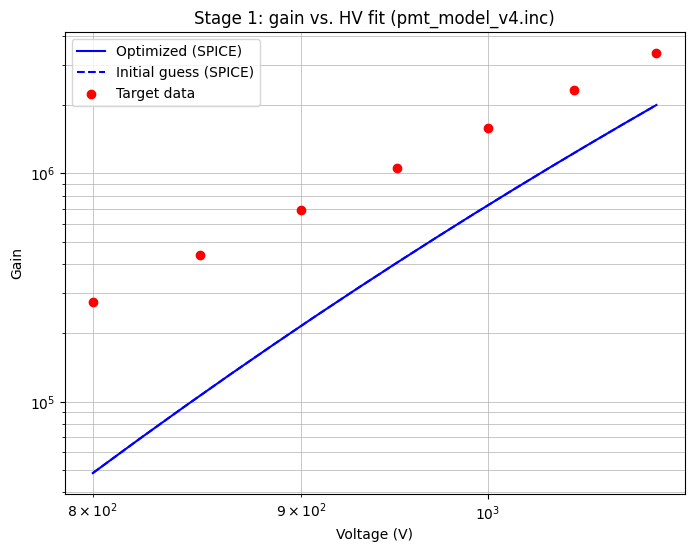

In [6]:
voltage_curve = np.linspace(target_voltage.min(), target_voltage.max(), 15)
initial_gain_curve = np.array([simulate_gain(v, N_PE_LINEAR, inc_params={"k": _k0, "a": _a0}) for v in voltage_curve])
final_gain_curve = np.array([simulate_gain(v, N_PE_LINEAR, inc_params={"k": best_k, "a": best_a}) for v in voltage_curve])

plt.figure(figsize=(8, 6))
plt.plot(voltage_curve, final_gain_curve, label='Optimized (SPICE)', color='blue')
plt.plot(voltage_curve, initial_gain_curve, label='Initial guess (SPICE)', color='blue', linestyle='--')
plt.scatter(target_voltage, target_gain, label='Target data', color='red', zorder=5)
plt.xlabel('Voltage (V)')
plt.ylabel('Gain')
plt.title('Stage 1: gain vs. HV fit (pmt_model_v4.inc)')
plt.legend()
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

## Stage 2: saturation vs. the PandaX Fig. 8 curve

The PandaX collaboration measured this same PMT model's charge-linearity by
comparing the *true* incident photoelectron count (from an independent estimate)
against the PMT's own *observed* (readout) charge, in units of kPE. At low light
the two track 1:1; at high light, space-charge saturation causes the observed
charge to fall below the true value -- i.e. points below the `y=x` line are direct
evidence of saturation, and how far below traces out the saturation curve. That
measured curve is the fit target for `Vknee, Vslope, Isc8, Isc9, Isc10, m` in
Stage 2 below.

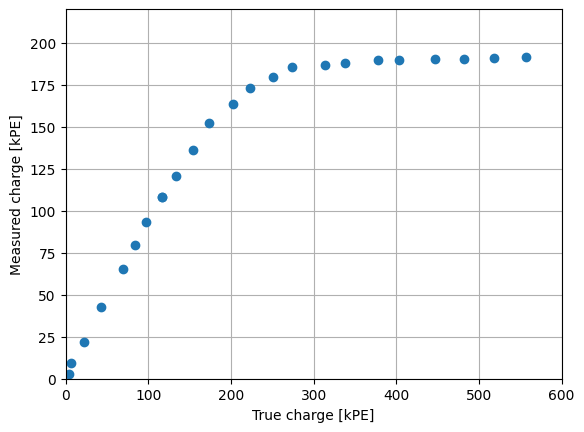

In [7]:
data = np.genfromtxt('PMT Saturation studies - R12699 - PandaX Fig 8.csv', \
    delimiter=',', skip_header=1)


plt.plot(data[:, 0], data[:, 1], 'o', label='Saturation curve')
plt.xlabel('True charge [kPE]')
plt.ylabel('Measured charge [kPE]')
plt.xlim(0.,600.)
plt.ylim(0.,220.)
plt.grid()



### From PandaX's "true charge" to `N_pe`

The CSV's `True charge` column is in kPE; multiplying by 1000 gives the number of
photoelectrons, `N_pe`, to actually drive into the SPICE model for each point. The
fit itself only uses every other point (`[::2]`, 12/24) to roughly halve the number
of SPICE runs per loss evaluation -- full digitized-point coverage is only used for
the baseline check below and the final validation plot.

In [8]:
from pmt_fit_helpers import stage2_loss, run_sim, simulate_gain, ELECTRON_CHARGE

# PandaX Fig 8 dataset: "True charge" (kPE) -> N_pe by x1000; "Observed charge" (kPE) is the fit target.
# Evaluated at the CSV's actual x-values (no interpolation), per the approved plan.
n_pe_values = data[:, 0] * 1000.0
target_charge_kpe = data[:, 1]

# Subsample to every third point for the fit itself -- cuts LTspice runs per loss
# evaluation to ~1/3, to keep individual optimizer iterations faster (2026-08-15 decision,
# after the every-other-point subsampling still made each eval too slow). Final
# validation/plot below still uses the full dataset.
n_pe_values_fit = n_pe_values[::3]
target_charge_kpe_fit = target_charge_kpe[::3]
print(f"Stage 2 fit uses {len(n_pe_values_fit)}/{len(n_pe_values)} PandaX points (every third point)")

# Vknee, Vslope: explicit new starting point (not read from pmt_model_v4.inc) -- a single
# Vknee now applies to every dynode gap including the anode (2026-08-16 decision, see the
# "eta" markdown above -- VkneeAnode was shown to have no real effect, so it's no longer a
# separate parameter). Starting at Vknee=35, Vslope=20 per that decision.
_Vknee0 = 35.0
_Vslope0 = 20.0
_Isc8_0 = get_param(_inc_text, "Isc8")
_Isc9_0 = get_param(_inc_text, "Isc9")
_Isc10_0 = get_param(_inc_text, "Isc10")
_m0 = get_param(_inc_text, "m")
initial_guess_2 = [_Vknee0, _Vslope0, _Isc8_0, _Isc9_0, _Isc10_0, _m0]
print("Stage 2 initial guess:", dict(zip(
    ["Vknee", "Vslope", "Isc8", "Isc9", "Isc10", "m"], initial_guess_2)))

# HV assumed to match whatever point the PandaX Fig 8 data was taken at -- the schematic's
# current default (1060V). No independent confirmation of this in the project files.
V1_STAGE2 = 1060.0

Stage 2 fit uses 8/24 PandaX points (every third point)
Stage 2 initial guess: {'Vknee': 35.0, 'Vslope': 20.0, 'Isc8': 0.8405294962, 'Isc9': 0.2027021462, 'Isc10': 0.1540646705, 'm': 1.797281632}


### Pre-fit sanity check: baseline model vs. PandaX (no fitting yet)

Before running Stage 2's optimizer, forward-simulate the model exactly as it's
currently tracked in `pmt_model_v4.inc` -- Stage 1's fitted `k,a`, plus whatever
saturation parameters happen to be seeded there right now (not yet fit to this
curve) -- and compare directly against the PandaX dataset. This is a look at
the starting point for Stage 2, not a fit result.

Also overlays a small `Vknee`/`Vslope` grid (everything else held at the tracked file's
current values): `Vknee` in `{20, 30, 40}` x `Vslope` in `{10, 20}`, six combinations
total. This replaces the earlier `VkneeAnode`-only and `VkneeOther`-only sweeps (both of
which used values too small to matter -- the earlier `VkneeOther` sweep used 10-20V
against dynode gaps that sit around 80-90V nominally, per the divider resistors; see the
project's PMT-gain-fit-status notes) now that `Vknee` is a single shared parameter. To
keep this quick, only every other PandaX point is simulated here.


Baseline (pre-Stage-2-fit) summary (every other PandaX point):
 True charge (kPE)   N_PE_obs (kPE)   PandaX observed (kPE)
             4.600            4.612                   3.040
            22.310           22.576                  22.140
            69.190           71.603                  65.560
            96.880          101.419                  93.340
           116.820          123.185                 108.110
           153.640          163.748                 135.900
           201.860          216.688                 163.270
           250.720          268.384                 179.790
           313.160          328.091                 186.780
           377.830          378.570                 189.430
           446.280          417.714                 190.340
           518.530          445.010                 190.830


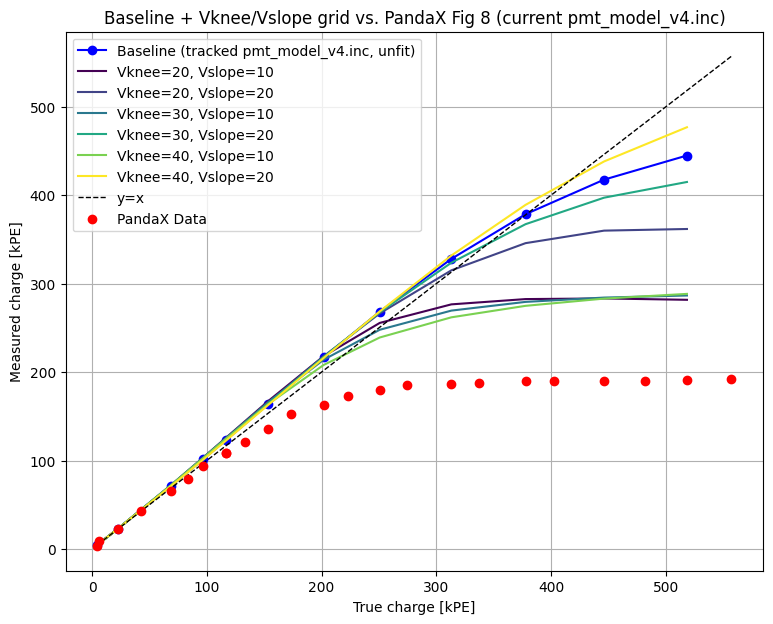

In [9]:
n_pe_values_explore = n_pe_values[::2]
target_charge_kpe_explore = target_charge_kpe[::2]

gain_ref_baseline = simulate_gain(V1_STAGE2, 10, run_name="ref_baseline")
N_PE_obs_baseline = np.array([
    abs(run_sim(v1=V1_STAGE2, n_pe=n_pe, run_name="pt_baseline"))
    / (ELECTRON_CHARGE * gain_ref_baseline)
    for n_pe in n_pe_values_explore
])

# Vknee x Vslope grid, holding everything else at the tracked pmt_model_v4.inc's current
# values (Isc8/9/10, m) -- isolates the effect of the single shared collection-efficiency
# knee/slope on the saturation curve shape.
knee_slope_trials = [
    (f"Vknee={vk}, Vslope={vs}", {"Vknee": float(vk), "Vslope": float(vs)})
    for vk in (20, 30, 40)
    for vs in (10, 20)
]

trial_curves = {}
for label, inc_params in knee_slope_trials:
    gain_ref_trial = simulate_gain(V1_STAGE2, 10, inc_params=inc_params, run_name="ref_trial")
    N_PE_obs_trial = np.array([
        abs(run_sim(v1=V1_STAGE2, n_pe=n_pe, inc_params=inc_params, run_name="pt_trial"))
        / (ELECTRON_CHARGE * gain_ref_trial)
        for n_pe in n_pe_values_explore
    ])
    trial_curves[label] = N_PE_obs_trial

print("\nBaseline (pre-Stage-2-fit) summary (every other PandaX point):")
print(f"{'True charge (kPE)':>18}  {'N_PE_obs (kPE)':>15}  {'PandaX observed (kPE)':>22}")
for true_kpe, obs_kpe, target_kpe in zip(n_pe_values_explore / 1e3, N_PE_obs_baseline / 1e3, target_charge_kpe_explore):
    print(f"{true_kpe:18.3f}  {obs_kpe:15.3f}  {target_kpe:22.3f}")

plt.figure(figsize=(9, 7))
plt.plot(n_pe_values_explore / 1e3, N_PE_obs_baseline / 1e3, 'o-', label='Baseline (tracked pmt_model_v4.inc, unfit)', color='blue')
_trial_colors = plt.cm.viridis(np.linspace(0, 1, len(knee_slope_trials)))
for (label, _), color in zip(knee_slope_trials, _trial_colors):
    plt.plot(n_pe_values_explore / 1e3, trial_curves[label] / 1e3, '-', label=label, color=color)
plt.plot(n_pe_values / 1e3, n_pe_values / 1e3, label='y=x', color='k', linestyle='--', linewidth=1)
plt.scatter(data[:, 0], data[:, 1], label='PandaX Data', color='red', zorder=5)
plt.xlabel('True charge [kPE]')
plt.ylabel('Measured charge [kPE]')
plt.title('Baseline + Vknee/Vslope grid vs. PandaX Fig 8 (current pmt_model_v4.inc)')
plt.legend()
plt.grid(True)
plt.show()

### Stage 2 fit: saturation parameters vs. PandaX

Free parameters: `Vknee, Vslope, Isc8, Isc9, Isc10, m` (6 total); `k, a` held
fixed at their Stage 1 values. For each candidate parameter vector, `stage2_loss`
first runs one low-current (`N_pe=10`) reference `.tran` to get an unsaturated
reference gain `gain_ref`, then for every PandaX point runs the real `.tran` and
converts the simulated anode charge to an "observed" PE count,

$$N_{\rm PE,\,obs} = \frac{Q_{\rm sim}}{e \cdot g_{\rm ref}}$$

Loss is the sum of squared residuals (linear scale, kPE) between $N_{\rm PE,\,obs}$
and PandaX's `Observed charge` column, minimized with `scipy.optimize.minimize`.

In [9]:
bounds_2 = [
    (0.5, 150),     # Vknee -- covers the ~80-90V nominal intermediate-dynode gap voltage
                    # (per the 1MOhm divider resistors) with headroom either side, so the
                    # starting point Vknee0=35 (2026-08-16) isn't pinned at either bound
    (0.2, 40),      # Vslope -- widened from 10 so starting at Vslope0=20 isn't pinned
                    # against the upper bound with no room to move up
    (0.01, 1.0),    # Isc8
    (0.005, 0.5),   # Isc9
    (0.002, 0.2),   # Isc10
    (0.3, 3.0),     # m
]

_cached2 = None
if USE_CACHED_FITS and STAGE2_CACHE.exists():
    _c = json.loads(STAGE2_CACHE.read_text())
    if _c.get("k") == best_k and _c.get("a") == best_a:
        _cached2 = _c
    else:
        print(f"Cached Stage 2 fit in {STAGE2_CACHE} was fit against a different k,a -- re-running.")

if _cached2 is not None:
    best_Vknee, best_Vslope, best_Isc8, best_Isc9, best_Isc10, best_m = (
        _cached2["Vknee"], _cached2["Vslope"], _cached2["Isc8"],
        _cached2["Isc9"], _cached2["Isc10"], _cached2["m"])
    print(f"Loaded cached Stage 2 fit from {STAGE2_CACHE} (loss={_cached2['loss']:.3e})")
else:
    print("Starting Stage 2 optimization (Vknee, Vslope, Isc8, Isc9, Isc10, m); "
          "k, a held fixed at Stage 1 values...")
    result2 = minimize(
        stage2_loss, initial_guess_2,
        args=(best_k, best_a, n_pe_values_fit, target_charge_kpe_fit, V1_STAGE2),
        bounds=bounds_2, method='Nelder-Mead',
        options={'xatol': 1e-3, 'fatol': 1e-3, 'maxiter': 800, 'maxfev': 800},
    )
    best_Vknee, best_Vslope, best_Isc8, best_Isc9, best_Isc10, best_m = result2.x
    print(f"\nStage 2 fit complete (loss={result2.fun:.3e}, {result2.nit} iters, {result2.nfev} evals, "
          f"converged={result2.success}):")
    print(f"  Vknee={best_Vknee:.4f}, Vslope={best_Vslope:.4f}")
    print(f"  Isc8={best_Isc8:.5f}, Isc9={best_Isc9:.5f}, Isc10={best_Isc10:.5f}, m={best_m:.4f}")
    STAGE2_CACHE.write_text(json.dumps({
        "k": best_k, "a": best_a,
        "Vknee": best_Vknee, "Vslope": best_Vslope,
        "Isc8": best_Isc8, "Isc9": best_Isc9, "Isc10": best_Isc10, "m": best_m,
        "loss": result2.fun, "nit": result2.nit, "nfev": result2.nfev,
        "success": bool(result2.success),
    }, indent=2))
    print(f"Saved fit to {STAGE2_CACHE}")

Loaded cached Stage 2 fit from stage2_fit_result.json (loss=4.569e+01)


In [10]:
inc_params_best = {
    "k": best_k, "a": best_a,
    "Vknee": best_Vknee, "Vslope": best_Vslope,
    "Isc8": best_Isc8, "Isc9": best_Isc9, "Isc10": best_Isc10, "m": best_m,
}
gain_ref_best = simulate_gain(V1_STAGE2, 10, inc_params=inc_params_best, run_name="ref_final")
N_PE_obs = np.array([
    abs(run_sim(v1=V1_STAGE2, n_pe=n_pe, inc_params=inc_params_best, run_name="pt_final"))
    / (ELECTRON_CHARGE * gain_ref_best)
    for n_pe in n_pe_values
])

In [11]:
print("\nSummary Table:")
print(f"{'True charge (kPE)':>18}  {'N_PE_obs (kPE)':>15}  {'PandaX observed (kPE)':>22}")
for true_kpe, obs_kpe, target_kpe in zip(n_pe_values / 1e3, N_PE_obs / 1e3, target_charge_kpe):
    print(f"{true_kpe:18.3f}  {obs_kpe:15.3f}  {target_kpe:22.3f}")


Summary Table:
 True charge (kPE)   N_PE_obs (kPE)   PandaX observed (kPE)
             4.600            4.615                   3.040
             6.190            6.217                   9.110
            22.310           22.549                  22.140
            43.070           43.548                  42.550
            69.190           69.163                  65.560
            83.800           82.769                  79.450
            96.880           94.361                  93.340
           116.820          110.769                 108.110
           116.820          110.769                 108.110
           133.700          123.336                 120.700
           153.640          136.527                 135.900
           173.600          147.927                 152.400
           201.860          161.129                 163.270
           223.270          169.045                 173.260
           250.720          176.922                 179.790
           274.360      

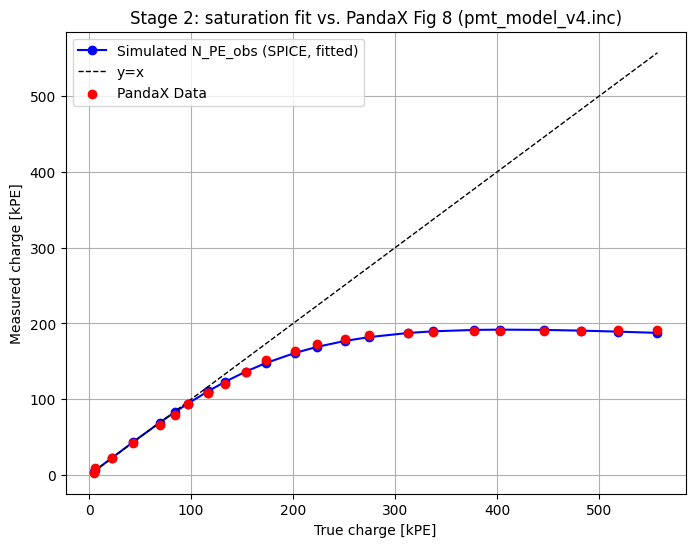

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(n_pe_values / 1e3, N_PE_obs / 1e3, 'o-', label='Simulated N_PE_obs (SPICE, fitted)', color='blue')
plt.plot(n_pe_values / 1e3, n_pe_values / 1e3, label='y=x', color='k', linestyle='--', linewidth=1)
plt.scatter(data[:, 0], data[:, 1], label='PandaX Data', color='red', zorder=5)
plt.xlabel('True charge [kPE]')
plt.ylabel('Measured charge [kPE]')
plt.title('Stage 2: saturation fit vs. PandaX Fig 8 (pmt_model_v4.inc)')
plt.legend()
plt.grid(True)
plt.show()

### Writing the fit back to `pmt_model_v4.inc`

This is the only cell in the notebook that mutates the tracked `pmt_model_v4.inc`
file itself -- every simulation above only ever touched scratch copies in
`fit_scratch/` during optimization.

In [13]:
# Write final best-fit parameters into the tracked pmt_model_v4.inc. This is the only
# point in the notebook that mutates the tracked file itself -- everything above only
# ever touched scratch copies during optimization.
from pmt_fit_helpers import set_param, BASE_INC

_final_params = {
    "k": best_k, "a": best_a,
    "Vknee": best_Vknee, "Vslope": best_Vslope,
    "Isc8": best_Isc8, "Isc9": best_Isc9, "Isc10": best_Isc10, "m": best_m,
}
_inc_final = BASE_INC.read_text()
for _name, _value in _final_params.items():
    _inc_final = set_param(_inc_final, _name, _value)
BASE_INC.write_text(_inc_final)

print(f"Wrote final best-fit values into {BASE_INC}:")
for _name, _value in _final_params.items():
    print(f"  {_name} = {_value:.6g}")

Wrote final best-fit values into /mnt/c/Users/bglen/Research/XLZD/PMT saturation/pmt_model_v4.inc:
  k = 0.122825
  a = 0.789952
  VkneeAnode = 5.88927
  Vslope = 2.35919
  Isc8 = 0.0840529
  Isc9 = 0.0202702
  Isc10 = 0.0154065
  m = 1.79728


### End-to-end consistency check

Re-simulate both the gain curve and the saturation curve directly from the
now-updated tracked `pmt_model_v4.inc`, with no parameter overrides and no further
fitting, and confirm they reproduce the in-memory fitted curves above -- a check
that the file on disk actually matches what the optimizer converged to.

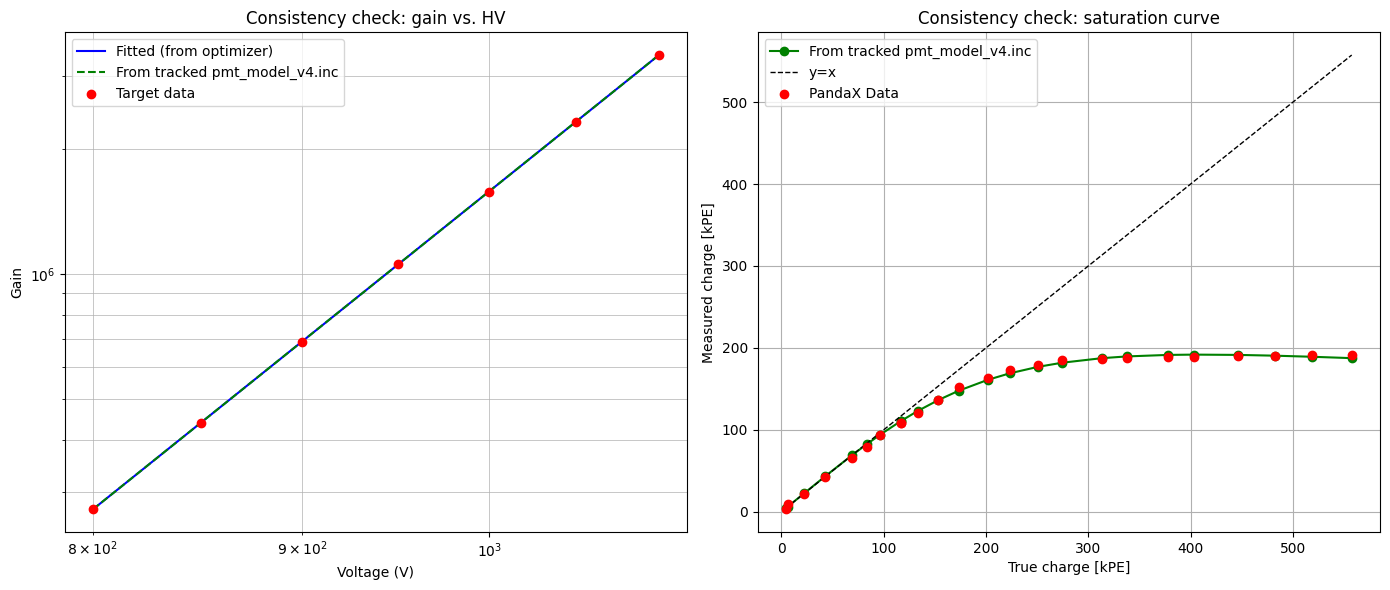

Max |log10(gain)| deviation between optimizer result and tracked-file readback: 1.27e-05
Max |N_PE_obs| deviation between optimizer result and tracked-file readback: 0.000 kPE


In [14]:
# End-to-end consistency check: forward-simulate both curves directly from the now-updated
# tracked pmt_model_v4.inc (no inc_params overrides, no further fitting) and confirm they
# reproduce the fitted curves above.
final_gain_check = np.array([simulate_gain(v, N_PE_LINEAR, run_name="final_check") for v in voltage_curve])

gain_ref_check = simulate_gain(V1_STAGE2, 10, run_name="ref_check")
N_PE_obs_check = np.array([
    abs(run_sim(v1=V1_STAGE2, n_pe=n_pe, run_name="pt_check")) / (ELECTRON_CHARGE * gain_ref_check)
    for n_pe in n_pe_values
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(voltage_curve, final_gain_curve, label='Fitted (from optimizer)', color='blue')
axes[0].plot(voltage_curve, final_gain_check, '--', label='From tracked pmt_model_v4.inc', color='green')
axes[0].scatter(target_voltage, target_gain, label='Target data', color='red', zorder=5)
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Gain')
axes[0].set_title('Consistency check: gain vs. HV')
axes[0].legend()
axes[0].grid(True, which='both', linestyle='-', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')

axes[1].plot(n_pe_values / 1e3, N_PE_obs_check / 1e3, 'o-', label='From tracked pmt_model_v4.inc', color='green')
axes[1].plot(n_pe_values / 1e3, n_pe_values / 1e3, 'k--', linewidth=1, label='y=x')
axes[1].scatter(data[:, 0], data[:, 1], label='PandaX Data', color='red', zorder=5)
axes[1].set_xlabel('True charge [kPE]')
axes[1].set_ylabel('Measured charge [kPE]')
axes[1].set_title('Consistency check: saturation curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

_max_gain_dev = np.max(np.abs(np.log10(final_gain_check) - np.log10(final_gain_curve)))
_max_charge_dev = np.max(np.abs(N_PE_obs_check - N_PE_obs))
print(f"Max |log10(gain)| deviation between optimizer result and tracked-file readback: {_max_gain_dev:.2e}")
print(f"Max |N_PE_obs| deviation between optimizer result and tracked-file readback: {_max_charge_dev:.3f} kPE")